In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Plot decay curve of star genes¶
MYC, PDLIM5, ACTB, GAPDH

MYC
Abundance.0h-1    0.990186
Abundance.0h-2    1.009814
Abundance.3h-1    0.020976
Abundance.3h-2    0.021566
Abundance.6h-1    0.013179
Abundance.6h-2    0.012228
Name: ENST00000621592.8, dtype: object
PDLIM5
Abundance.0h-1    1.008521
Abundance.0h-2    0.991479
Abundance.3h-1    0.624894
Abundance.3h-2    0.640365
Abundance.6h-1    0.472928
Abundance.6h-2    0.501038
Name: ENST00000317968.9, dtype: object
ACTB
Abundance.0h-1    0.988236
Abundance.0h-2    1.011764
Abundance.3h-1    0.800104
Abundance.3h-2     0.83547
Abundance.6h-1     0.65354
Abundance.6h-2    0.651785
Name: ENST00000646664.1, dtype: object
GAPDH
Abundance.0h-1     0.98834
Abundance.0h-2     1.01166
Abundance.3h-1    0.928786
Abundance.3h-2    0.979033
Abundance.6h-1     0.86657
Abundance.6h-2    0.836817
Name: ENST00000229239.10, dtype: object


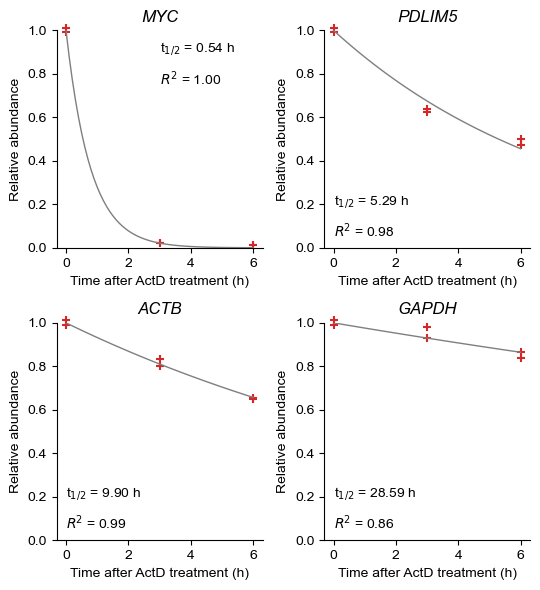

In [6]:
df = pd.read_csv("results/halflife_of_k562_genes.tsv", sep="\t", index_col=0)
df["T"] = df["Halflife"]
columns = ["0h-1", "0h-2", "3h-1", "3h-2", "6h-1", "6h-2"]
tids = [
    "ENST00000621592.8", # MYC
    "ENST00000317968.9", # PDLIM5
    "ENST00000646664.1", # ACTB
    "ENST00000229239.10", # GAPDH
]

fig, axs = plt.subplots(2, 2, figsize=(5.5, 6), sharex=False, sharey=False)
for i, tid in enumerate(tids):
    m = int(i / 2)
    n = i % 2
    plt.sca(axs[m][n])
    
    T = df.loc[tid]["T"]
    D = df.loc[tid]["DecayRate.R2Score"]
    gname = df.loc[tid]["GeneName"]
    xs = np.array([0, 0, 3, 3, 6, 6])
    ys = df.loc[tid][["Abundance.%s" % c for c in columns]]
    print(gname)
    print(ys)
    xs1 = np.arange(0, 6.1, 0.1)
    ys1 = np.array([0.5**(x/T)for x in xs1])
    
    plt.title(gname, style="italic")
    plt.scatter(xs, ys, color="C3", marker="+", clip_on=False)
    plt.plot(xs1, ys1, lw=1, color="C7")
    if gname == "MYC":
        plt.text(3, 0.9, "t$_{1/2}$ = %.2f h" % T)
        plt.text(3, 0.75, "$R^2$ = %.2f" % D)
    else:
        plt.text(0, 0.2, "t$_{1/2}$ = %.2f h" % T)
        plt.text(0, 0.05, "${R}$$^{\mathit{2}}$ = %.2f" % D)
    #if m == 1:
    plt.xlabel("Time after ActD treatment (h)")
    #if n == 0:
    plt.ylabel("Relative abundance")
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("figures/decay_curve.example_genes.pdf")